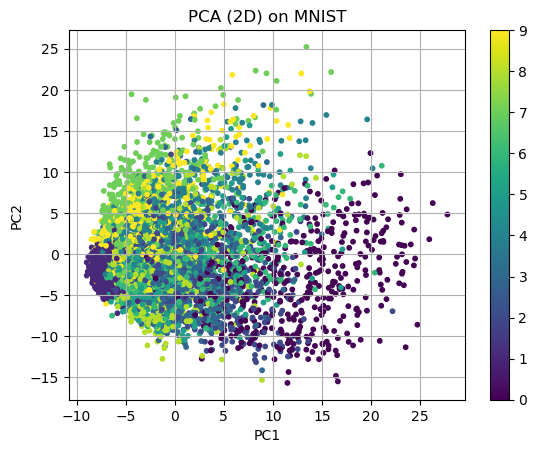

Explained variance ratio: [0.06120767 0.04537228]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load MNIST (subset for speed)
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data[:5000]
y = mnist.target[:5000].astype(int)

# Standardize
X_scaled = StandardScaler().fit_transform(X)

# PCA to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure()
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, s=10)
plt.colorbar(scatter)
plt.title("PCA (2D) on MNIST")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

In [4]:
pca = PCA(n_components=100)
X_reduced = pca.fit_transform(X_scaled)

print("Total variance retained:", np.sum(pca.explained_variance_ratio_))

Total variance retained: 0.7746823329405542


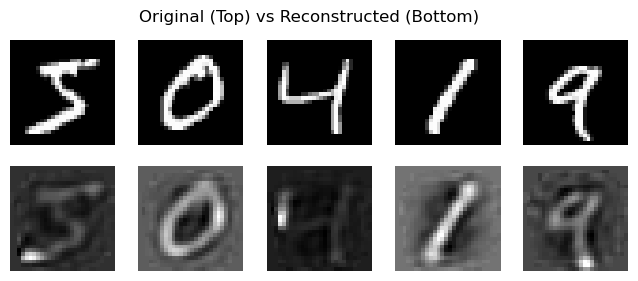

In [5]:
# Reconstruct digits
X_reconstructed = pca.inverse_transform(X_reduced)

# Show original vs reconstructed
plt.figure(figsize=(8,3))

for i in range(5):
    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(X[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # Reconstructed
    plt.subplot(2,5,i+6)
    plt.imshow(X_reconstructed[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.suptitle("Original (Top) vs Reconstructed (Bottom)")
plt.show()

In [6]:
mnist.data.shape

(70000, 784)